# CRISP-DM: Fraud Detection Pipeline
## Predicting `is_fraud` in the Orders Table

Contributors: Waylan Abbott, Micheal Hawkins, Reece Williams, Mitchle Franks

This notebook follows the **CRISP-DM** framework to build a complete fraud detection model using the `shop.db` operational database.

| CRISP-DM Phase | Chapters Covered |
|---|---|
| Business Understanding | Problem framing, success criteria |
| Data Understanding | Ch. 6 (feature exploration), Ch. 8 (relationships) |
| Data Preparation | Ch. 2–4 (wrangling/cleaning), Ch. 7 (automated pipelines) |
| Modeling | Ch. 13 (classification), Ch. 14 (ensemble methods) |
| Evaluation | Ch. 15 (model evaluation/selection/tuning), Ch. 16 (feature selection) |
| Deployment | Ch. 17 (serialize model, integrate into pipeline) |

---
## Phase 1: Business Understanding

**Problem:** Our e-commerce platform processes thousands of orders. A small fraction (≈6.4%) are fraudulent. Undetected fraud leads to chargebacks, lost revenue, and damaged customer trust.

**Objective:** Build a binary classification model that predicts whether an order is fraudulent (`is_fraud = 1`) at the time of placement, enabling the operations team to flag and review high-risk orders before fulfillment.

**Success Criteria:**
- **ROC-AUC ≥ 0.80** — the model should discriminate well between fraud and legitimate orders
- **Recall (fraud class) ≥ 0.60** — we'd rather flag some legitimate orders for review than miss real fraud
- **Precision (fraud class) ≥ 0.30** — keep the review queue manageable so analysts aren't overwhelmed with false positives

**Stakeholders:** Fraud operations team, customer experience, finance (chargeback reduction).

---
## Phase 2: Data Understanding

### 2.1 — Load Data from SQLite (Ch. 6)

In [22]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

DB_PATH = Path('../data/shop.db')
conn = sqlite3.connect(DB_PATH)

# Load all tables
customers = pd.read_sql('SELECT * FROM customers', conn)
orders = pd.read_sql('SELECT * FROM orders', conn)
order_items = pd.read_sql('SELECT * FROM order_items', conn)
products = pd.read_sql('SELECT * FROM products', conn)
shipments = pd.read_sql('SELECT * FROM shipments', conn)
reviews = pd.read_sql('SELECT * FROM product_reviews', conn)

print('Table shapes:')
for name, df in [('customers', customers), ('orders', orders), ('order_items', order_items),
                  ('products', products), ('shipments', shipments), ('reviews', reviews)]:
    print(f'  {name:15s} {df.shape}')

Table shapes:
  customers       (250, 12)
  orders          (5000, 17)
  order_items     (15022, 6)
  products        (100, 7)
  shipments       (5000, 9)
  reviews         (3000, 6)


In [23]:
# Quick look at orders — our primary table
orders.head()

,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,promo_code,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,None,662.95,15.44,46.30,724.69,38.3,0
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,SAVE10,862.92,14.74,66.61,944.27,94.9,0
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,None,796.09,14.04,40.72,850.85,53.8,1
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,WELCOME,137.60,6.99,11.88,156.47,4.2,0
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,None,17.07,6.99,1.40,25.46,4.9,0


In [24]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        5000 non-null   int64  
 1   customer_id     5000 non-null   int64  
 2   order_datetime  5000 non-null   object 
 3   billing_zip     5000 non-null   object 
 4   shipping_zip    5000 non-null   object 
 5   shipping_state  5000 non-null   object 
 6   payment_method  5000 non-null   object 
 7   device_type     5000 non-null   object 
 8   ip_country      5000 non-null   object 
 9   promo_used      5000 non-null   int64  
 10  promo_code      1261 non-null   object 
 11  order_subtotal  5000 non-null   float64
 12  shipping_fee    5000 non-null   float64
 13  tax_amount      5000 non-null   float64
 14  order_total     5000 non-null   float64
 15  risk_score      5000 non-null   float64
 16  is_fraud        5000 non-null   int64  
dtypes: float64(5), int64(4), object(8

In [25]:
orders.describe()

,order_id,customer_id,promo_used,order_subtotal,shipping_fee,tax_amount,order_total,risk_score,is_fraud
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,28.448200,0.252200,384.144678,9.668290,27.738312,421.551280,26.115940,0.063600
std,1443.520003,49.086939,0.434319,284.124017,5.126125,21.446470,305.183694,27.433842,0.244063
min,1.000000,1.000000,0.000000,4.730000,0.000000,0.250000,5.380000,0.100000,0.000000
25%,1250.750000,2.000000,0.000000,164.180000,6.990000,11.470000,185.760000,4.600000,0.000000
50%,2500.500000,6.000000,0.000000,330.720000,8.040000,23.365000,364.835000,14.500000,0.000000
75%,3750.250000,28.000000,1.000000,549.752500,12.990000,39.152500,596.940000,40.225000,0.000000
max,5000.000000,250.000000,1.000000,1921.170000,28.140000,148.130000,2053.110000,100.000000,1.000000


### 2.2 — Target Variable Distribution

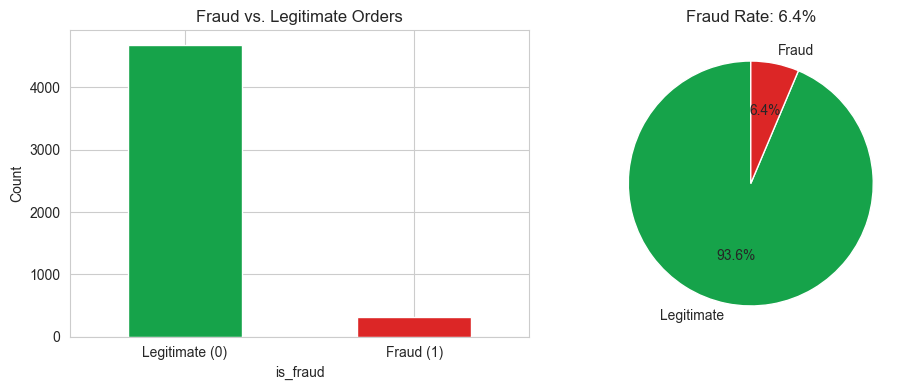

Total orders: 5000
Fraud orders: 318 (6.4%)
Legitimate:   4682 (93.6%)

This is an IMBALANCED dataset — we will need class weighting or resampling.


In [26]:
fraud_counts = orders['is_fraud'].value_counts()
fraud_pct = orders['is_fraud'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

fraud_counts.plot.bar(ax=axes[0], color=['#16a34a', '#dc2626'])
axes[0].set_title('Fraud vs. Legitimate Orders')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'], rotation=0)
axes[0].set_ylabel('Count')

axes[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.1f%%',
            colors=['#16a34a', '#dc2626'], startangle=90)
axes[1].set_title(f'Fraud Rate: {fraud_pct:.1f}%')

plt.tight_layout()
plt.show()

print(f'Total orders: {len(orders)}')
print(f'Fraud orders: {fraud_counts[1]} ({fraud_pct:.1f}%)')
print(f'Legitimate:   {fraud_counts[0]} ({100-fraud_pct:.1f}%)')
print(f'\nThis is an IMBALANCED dataset — we will need class weighting or resampling.')

### 2.3 — Feature-Level Exploration (Ch. 6)

Explore distributions and relationships of key features with the target.

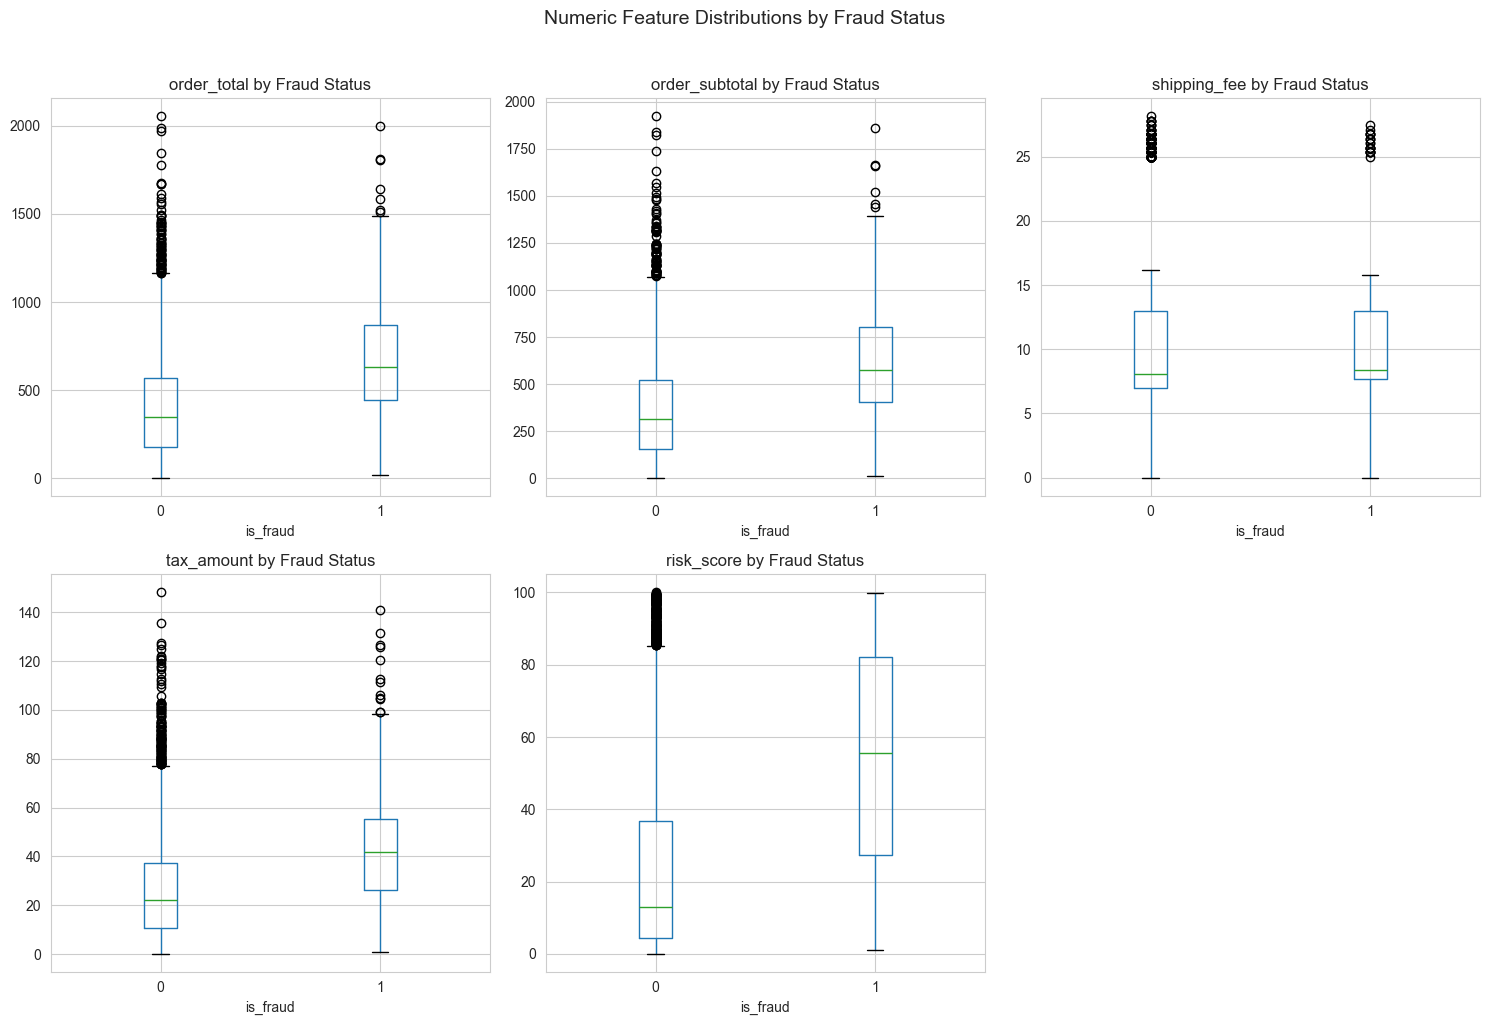

In [27]:
# Numeric feature distributions by fraud status
num_features = ['order_total', 'order_subtotal', 'shipping_fee', 'tax_amount', 'risk_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    orders.boxplot(column=col, by='is_fraud', ax=axes[i])
    axes[i].set_title(f'{col} by Fraud Status')
    axes[i].set_xlabel('is_fraud')

axes[5].axis('off')
plt.suptitle('Numeric Feature Distributions by Fraud Status', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

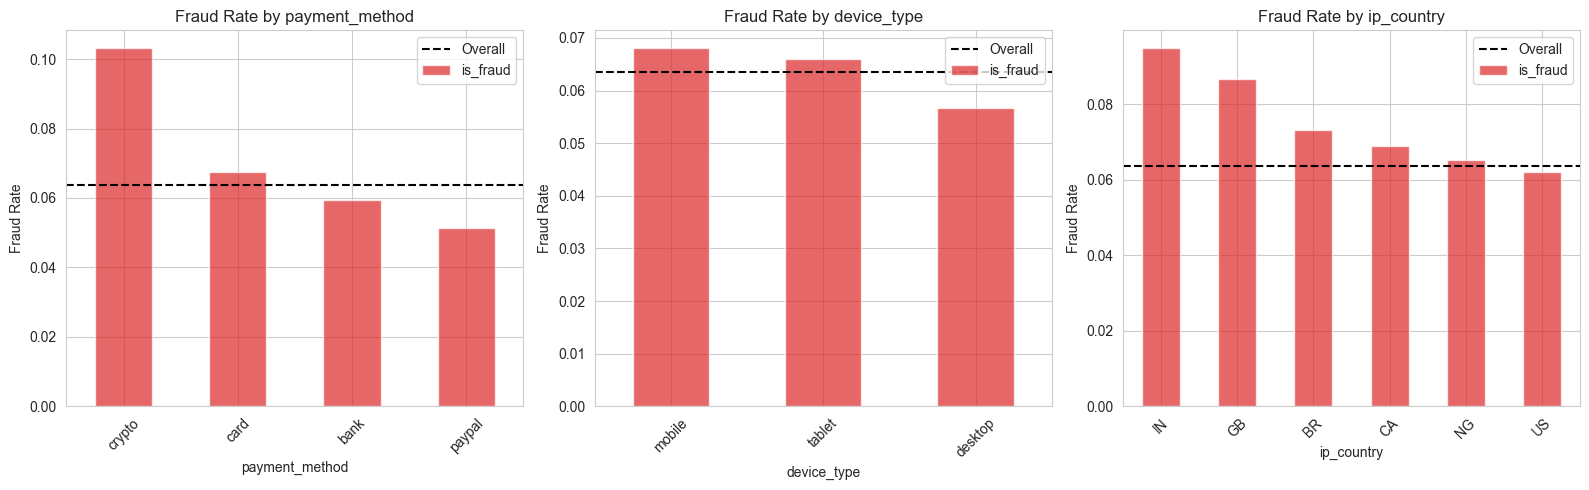

In [28]:
# Categorical feature fraud rates
cat_features = ['payment_method', 'device_type', 'ip_country']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(cat_features):
    fraud_rate = orders.groupby(col)['is_fraud'].mean().sort_values(ascending=False)
    fraud_rate.plot.bar(ax=axes[i], color='#dc2626', alpha=0.7)
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud Rate')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(y=orders['is_fraud'].mean(), color='black', linestyle='--', label='Overall')
    axes[i].legend()

plt.tight_layout()
plt.show()

### 2.4 — Discover Relationships (Ch. 8)

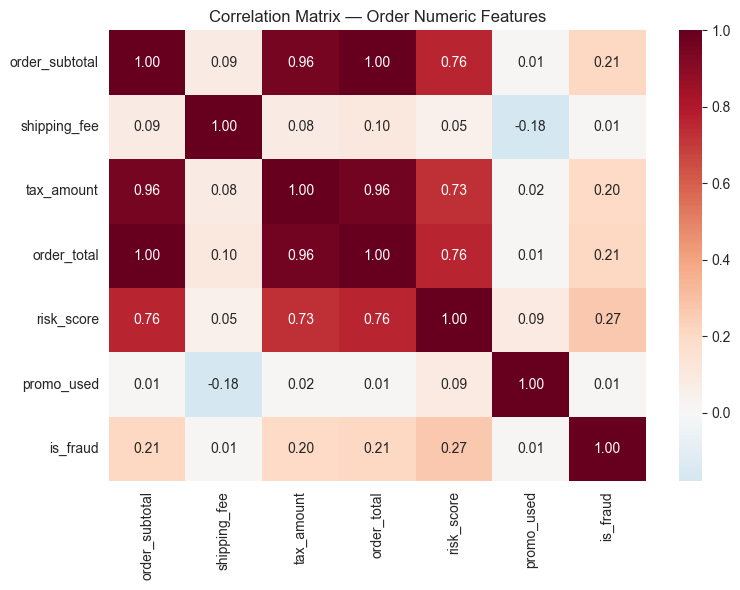

In [29]:
# Correlation heatmap for numeric columns
numeric_orders = orders[['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total',
                          'risk_score', 'promo_used', 'is_fraud']]

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_orders.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix — Order Numeric Features')
plt.tight_layout()
plt.show()

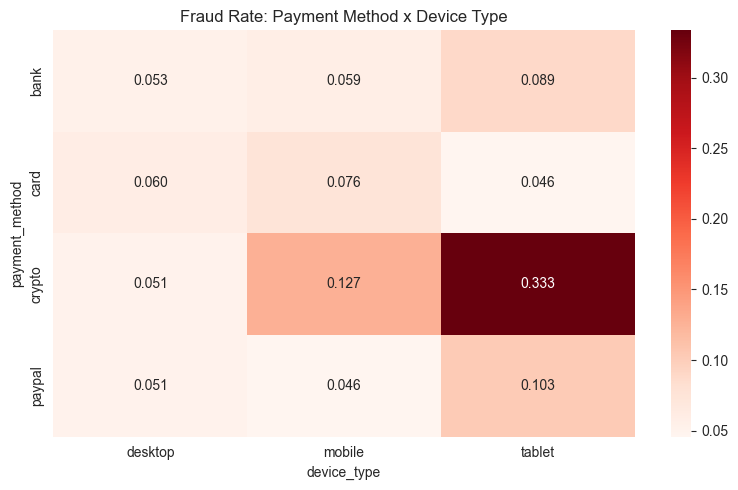

In [30]:
# Cross-tabulation: payment_method x device_type fraud rates
ct = pd.crosstab(orders['payment_method'], orders['device_type'],
                  values=orders['is_fraud'], aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt='.3f', cmap='Reds')
plt.title('Fraud Rate: Payment Method x Device Type')
plt.tight_layout()
plt.show()

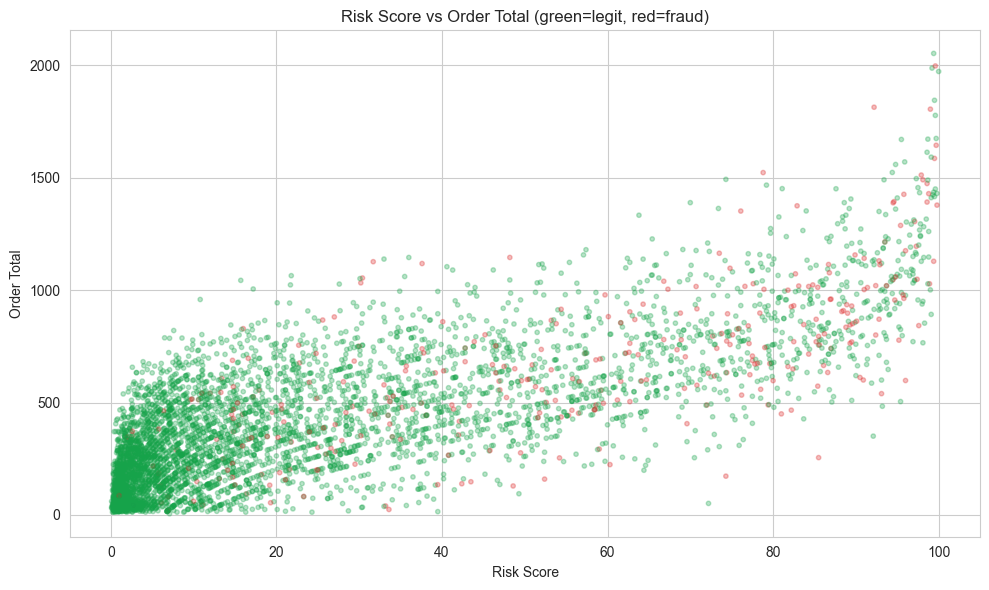

In [31]:
# Scatter: risk_score vs order_total colored by fraud
plt.figure(figsize=(10, 6))
colors = orders['is_fraud'].map({0: '#16a34a', 1: '#dc2626'})
plt.scatter(orders['risk_score'], orders['order_total'], c=colors, alpha=0.3, s=10)
plt.xlabel('Risk Score')
plt.ylabel('Order Total')
plt.title('Risk Score vs Order Total (green=legit, red=fraud)')
plt.tight_layout()
plt.show()

---
## Phase 3: Data Preparation

### 3.1 — Data Wrangling & Cleaning (Ch. 2–4)

In [32]:
# Check for missing values
print('Missing values in orders:')
print(orders.isnull().sum())
print(f'\nTotal nulls: {orders.isnull().sum().sum()}')

Missing values in orders:
order_id             0
customer_id          0
order_datetime       0
billing_zip          0
shipping_zip         0
shipping_state       0
payment_method       0
device_type          0
ip_country           0
promo_used           0
promo_code        3739
order_subtotal       0
shipping_fee         0
tax_amount           0
order_total          0
risk_score           0
is_fraud             0
dtype: int64

Total nulls: 3739


In [33]:
# Check for duplicates
print(f'Duplicate order_ids: {orders["order_id"].duplicated().sum()}')
print(f'Duplicate rows:      {orders.duplicated().sum()}')

Duplicate order_ids: 0
Duplicate rows:      0


In [34]:
# Aggregate order_items per order
item_agg = (
    order_items.groupby('order_id')
    .agg(
        num_items=('quantity', 'sum'),
        num_distinct_products=('product_id', 'nunique'),
        avg_unit_price=('unit_price', 'mean'),
        max_unit_price=('unit_price', 'max'),
        min_unit_price=('unit_price', 'min'),
    )
    .reset_index()
)

print(f'Order-item aggregates: {item_agg.shape}')
item_agg.head()

Order-item aggregates: (5000, 6)


,order_id,num_items,num_distinct_products,avg_unit_price,max_unit_price,min_unit_price
0,1,9,5,69.242,99.90,23.16
1,2,7,5,133.300,241.51,47.27
2,3,5,3,140.850,230.50,49.01
3,4,1,1,137.600,137.60,137.60
4,5,1,1,17.070,17.07,17.07


### 3.2 — Feature Engineering

In [35]:
# Build the analytical dataset by joining tables
df = (
    orders
    .merge(customers[['customer_id', 'gender', 'customer_segment', 'loyalty_tier',
                       'city', 'state']],
           on='customer_id', how='left', suffixes=('', '_cust'))
    .merge(item_agg, on='order_id', how='left')
    .merge(shipments[['order_id', 'carrier', 'shipping_method', 'distance_band']],
           on='order_id', how='left')
)

# Engineered features
df['zip_mismatch'] = (df['billing_zip'] != df['shipping_zip']).astype(int)
df['is_foreign_ip'] = (df['ip_country'] != 'US').astype(int)
df['order_hour'] = pd.to_datetime(df['order_datetime']).dt.hour
df['order_dayofweek'] = pd.to_datetime(df['order_datetime']).dt.dayofweek
df['shipping_ratio'] = df['shipping_fee'] / (df['order_subtotal'] + 0.01)
df['price_range'] = df['max_unit_price'] - df['min_unit_price']

print(f'Final dataset: {df.shape}')
print(f'\nEngineered features: zip_mismatch, is_foreign_ip, order_hour, order_dayofweek, shipping_ratio, price_range')
df.head()

Final dataset: (5000, 36)

Engineered features: zip_mismatch, is_foreign_ip, order_hour, order_dayofweek, shipping_ratio, price_range


,order_id,customer_id,order_datetime,billing_zip,shipping_zip,shipping_state,payment_method,device_type,ip_country,promo_used,...,min_unit_price,carrier,shipping_method,distance_band,zip_mismatch,is_foreign_ip,order_hour,order_dayofweek,shipping_ratio,price_range
0,1,1,2025-11-29 00:51:07,28289,28289,CO,card,mobile,US,0,...,23.16,UPS,expedited,regional,0,0,0,5,0.023289,76.74
1,2,1,2025-09-01 10:25:59,28289,13888,NY,card,desktop,US,1,...,47.27,FedEx,expedited,local,1,0,10,0,0.017081,194.24
2,3,1,2025-12-15 07:24:41,28289,28289,CO,card,mobile,US,0,...,49.01,FedEx,expedited,national,0,0,7,0,0.017636,181.49
3,4,1,2025-11-06 18:21:19,28289,28289,CO,bank,mobile,US,1,...,137.60,UPS,standard,regional,0,0,18,3,0.050796,0.00
4,5,1,2025-11-30 05:34:15,28289,28289,CO,card,mobile,CA,0,...,17.07,USPS,standard,regional,0,1,5,6,0.409251,0.00


### 3.3 — Automated Preparation Pipeline (Ch. 7)

In [36]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define feature groups
categorical_cols = [
    'payment_method', 'device_type', 'ip_country',
    'gender', 'customer_segment', 'loyalty_tier',
    'carrier', 'shipping_method', 'distance_band',
]

numeric_cols = [
    'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total',
    'risk_score', 'promo_used',
    'num_items', 'num_distinct_products', 'avg_unit_price', 'max_unit_price',
    'zip_mismatch', 'is_foreign_ip', 'order_hour', 'order_dayofweek',
    'shipping_ratio', 'price_range',
]

target = 'is_fraud'

X = df[categorical_cols + numeric_cols].copy()
y = df[target].copy()

print(f'X shape: {X.shape}')
print(f'Categorical features: {len(categorical_cols)}')
print(f'Numeric features:     {len(numeric_cols)}')
print(f'Fraud rate:           {y.mean():.1%}')

X shape: (5000, 25)
Categorical features: 9
Numeric features:     16
Fraud rate:           6.4%


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} ({y_train.mean():.1%} fraud)')
print(f'Test:  {X_test.shape[0]} ({y_test.mean():.1%} fraud)')

Train: 4000 (6.3% fraud)
Test:  1000 (6.4% fraud)


In [38]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ]
)

# Verify it works
X_train_transformed = preprocessor.fit_transform(X_train)
print(f'Transformed feature matrix: {X_train_transformed.shape}')

Transformed feature matrix: (4000, 47)


---
## Phase 4: Modeling

### 4.1 — Baseline: Logistic Regression (Ch. 13)

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

print('=== Logistic Regression (Baseline) ===')
print(classification_report(y_test, lr_pred, target_names=['Legit', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}')

=== Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

       Legit       0.97      0.77      0.86       936
       Fraud       0.16      0.62      0.25        64

    accuracy                           0.76      1000
   macro avg       0.56      0.70      0.55      1000
weighted avg       0.92      0.76      0.82      1000

ROC-AUC: 0.7450


### 4.2 — Random Forest (Ch. 14 — Ensemble Methods)

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    )),
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, rf_pred, target_names=['Legit', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}')

=== Random Forest ===
              precision    recall  f1-score   support

       Legit       0.94      0.99      0.96       936
       Fraud       0.18      0.03      0.05        64

    accuracy                           0.93      1000
   macro avg       0.56      0.51      0.51      1000
weighted avg       0.89      0.93      0.90      1000

ROC-AUC: 0.7277


### 4.3 — Gradient Boosting (Ch. 14 — Ensemble Methods)

In [41]:
from sklearn.ensemble import GradientBoostingClassifier

# For GBM, we need to handle class imbalance via sample_weight
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
    )),
])

# Compute sample weights for imbalanced classes
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

gb_pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weights)
gb_pred = gb_pipeline.predict(X_test)
gb_prob = gb_pipeline.predict_proba(X_test)[:, 1]

print('=== Gradient Boosting ===')
print(classification_report(y_test, gb_pred, target_names=['Legit', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, gb_prob):.4f}')

=== Gradient Boosting ===
              precision    recall  f1-score   support

       Legit       0.94      0.95      0.95       936
       Fraud       0.16      0.14      0.15        64

    accuracy                           0.90      1000
   macro avg       0.55      0.55      0.55      1000
weighted avg       0.89      0.90      0.90      1000

ROC-AUC: 0.7084


---
## Phase 5: Evaluation

### 5.1 — Model Comparison (Ch. 15)

In [42]:
from sklearn.metrics import RocCurveDisplay

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob),
    ],
    'Fraud Recall': [
        classification_report(y_test, lr_pred, output_dict=True)['Fraud']['recall'],
        classification_report(y_test, rf_pred, output_dict=True)['Fraud']['recall'],
        classification_report(y_test, gb_pred, output_dict=True)['Fraud']['recall'],
    ],
    'Fraud Precision': [
        classification_report(y_test, lr_pred, output_dict=True)['Fraud']['precision'],
        classification_report(y_test, rf_pred, output_dict=True)['Fraud']['precision'],
        classification_report(y_test, gb_pred, output_dict=True)['Fraud']['precision'],
    ],
})

print(results.to_string(index=False))

KeyError: 'Fraud'

In [ ]:
# ROC curves side by side
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, lr_prob, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_prob, name='Random Forest', ax=ax)
RocCurveDisplay.from_predictions(y_test, gb_prob, name='Gradient Boosting', ax=ax)

ax.set_title('ROC Curve Comparison')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrices for all three models
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, pred, name in zip(axes, [lr_pred, rf_pred, gb_pred],
                            ['Logistic Regression', 'Random Forest', 'Gradient Boosting']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=['Legit', 'Fraud'], ax=ax, cmap='Blues'
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

### 5.2 — Hyperparameter Tuning (Ch. 15)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Tune the best-performing model
# Using RandomForest with balanced class weights
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [8, 12, 16, None],
    'classifier__min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV ROC-AUC: {grid_search.best_score_:.4f}')

In [ ]:
# Evaluate tuned model on test set
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print('=== Tuned Random Forest ===')
print(classification_report(y_test, best_pred, target_names=['Legit', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, best_prob):.4f}')

### 5.3 — Feature Selection (Ch. 16)

In [ ]:
# Feature importances from the best model
ohe_names = best_model.named_steps['preprocessor'].transformers_[0][1].get_feature_names_out(categorical_cols)
all_feature_names = list(ohe_names) + numeric_cols
importances = best_model.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

# Top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).plot.barh(ax=ax, color='#2563eb')
ax.invert_yaxis()
ax.set_title('Top 20 Feature Importances (Tuned Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# Permutation importance for more robust feature selection
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=10, random_state=42, scoring='roc_auc', n_jobs=-1
)

# Aggregate by original feature (not one-hot encoded)
perm_imp = pd.Series(perm_result.importances_mean, index=all_feature_names)

# Show top 15 permutation importances
top_perm = perm_imp.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_perm.plot.barh(ax=ax, color='#d97706')
ax.invert_yaxis()
ax.set_title('Top 15 Permutation Importances (ROC-AUC)')
ax.set_xlabel('Mean AUC Decrease')
plt.tight_layout()
plt.show()

In [ ]:
# Cross-validation score summary
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='roc_auc', n_jobs=-1)

print(f'5-Fold Cross-Validation ROC-AUC:')
print(f'  Scores: {cv_scores.round(4)}')
print(f'  Mean:   {cv_scores.mean():.4f}')
print(f'  Std:    {cv_scores.std():.4f}')

---
## Phase 6: Deployment (Ch. 17)

### 6.1 — Serialize the Trained Model

In [ ]:
import pickle

MODEL_PATH = Path('../jobs/model.pkl')

model_bundle = {
    'pipeline': best_model,
    'categorical_cols': categorical_cols,
    'numeric_cols': numeric_cols,
    'target': target,
    'training_date': pd.Timestamp.now().isoformat(),
    'training_rows': len(X_train),
    'test_auc': roc_auc_score(y_test, best_prob),
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f'Model saved to {MODEL_PATH.resolve()}')
print(f'Bundle keys: {list(model_bundle.keys())}')

### 6.2 — Write Warehouse Table to Database

In [ ]:
# Save the analytical warehouse table back to the operational database
df.to_sql('warehouse_fraud', conn, if_exists='replace', index=False)
print(f'Wrote warehouse_fraud table ({len(df)} rows) to shop.db')

### 6.3 — Generate Predictions & Write Back to Database

In [ ]:
# Score ALL orders and write to order_predictions table
all_probs = best_model.predict_proba(X)[:, 1]
all_preds = (all_probs >= 0.5).astype(int)

predictions = pd.DataFrame({
    'order_id': df['order_id'],
    'fraud_probability': all_probs.round(4),
    'predicted_fraud': all_preds,
    'scored_at': pd.Timestamp.now().isoformat(),
})

# Clear and rewrite
conn.execute('DELETE FROM order_predictions')
predictions.to_sql('order_predictions', conn, if_exists='append', index=False)
conn.commit()

print(f'Scored {len(predictions)} orders')
print(f'Flagged as fraud: {all_preds.sum()} ({all_preds.mean():.1%})')
print(f'\nPredictions written to order_predictions table in shop.db')

### 6.4 — Integration with Inference Pipeline

The serialized model integrates into the deployed system via `jobs/run_inference.py`, which:

1. Loads `model.pkl`
2. Queries unscored orders from the database
3. Applies the same feature engineering
4. Generates predictions
5. Writes results to the `order_predictions` table

The web application's **"Run Scoring"** button triggers this script, and the results appear in the dashboard and order detail pages.

In [ ]:
# Verify the pipeline works end-to-end by reading back from DB
verification = pd.read_sql("""
    SELECT p.order_id, p.fraud_probability, p.predicted_fraud, o.is_fraud
    FROM order_predictions p
    JOIN orders o ON p.order_id = o.order_id
    ORDER BY p.fraud_probability DESC
    LIMIT 10
""", conn)

print('Top 10 highest fraud probability orders:')
print(verification.to_string(index=False))

In [ ]:
conn.close()

print('\n=== CRISP-DM Pipeline Complete ===')
print(f'Model: Tuned Random Forest')
print(f'Best params: {grid_search.best_params_}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, best_prob):.4f}')
print(f'5-Fold CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Model saved to: jobs/model.pkl')
print(f'Predictions in: order_predictions table')